# Part 1 : Transfer Learning Using VGG16

## Step 1 : import libraries

In [ ]:
!pip install tensorflow
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install opencv-python
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.5 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Step 2 : Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/archive"
data_train_path = "/content/drive/MyDrive/archive/train"
data_test_path = "/content/drive/MyDrive/archive/test"
data_val_path = "/content/drive/MyDrive/archive/val"

In [ ]:
imgw, imgh = 224, 224

data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path, image_size=(imgw, imgh), batch_size=32,
    shuffle=True, label_mode="int"
)
class_names = data_train.class_names

data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path, image_size=(imgw, imgh), batch_size=32,
    shuffle=False, label_mode="int", class_names=class_names
)
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path, image_size=(imgw, imgh), batch_size=32,
    shuffle=False, label_mode="int", class_names=class_names
)
print("Classes:", class_names)

Found 929 files belonging to 6 classes.
Found 550 files belonging to 6 classes.
Found 95 files belonging to 6 classes.
Classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


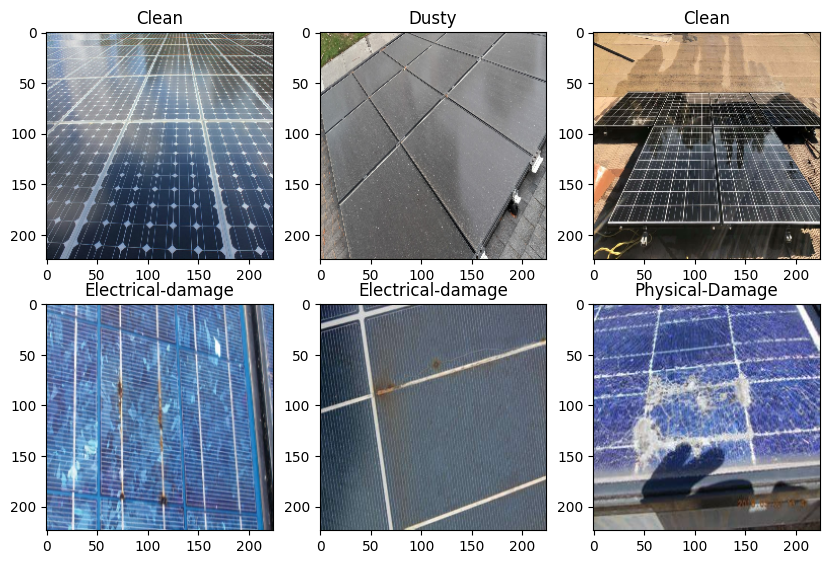

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in data_train.take(1):
  for i in range(6):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

data_train = data_train.map(lambda x, y: (preprocess_input(x), y))
data_val = data_val.map(lambda x, y: (preprocess_input(x), y))
data_test = data_test.map(lambda x, y: (preprocess_input(x), y))


## Step 3 : Load the pre-trained VGG16 model (without top layers) and Freeze the convolution layers

## Step 4 : Add new fully connected layers (custom head)

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation, RandomZoom

def build_transfer_model(base_model, num_classes):
    """
    Build a transfer learning model using Sequential and add data augmentation at the top.
    """
    # Step 1: Create data augmentation layer
    data_augmentation = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.1),
    ], name="data_augmentation")

    # Step 2: Build the full model using Sequential
    model = Sequential()
    model.add(data_augmentation)                 # Apply augmentation first
    model.add(base_model)                        # Add frozen base model
    model.add(GlobalAveragePooling2D())          # Global pooling after conv layers
    model.add(Dense(1024, activation='relu'))    # Fully connected layer
    model.add(Dropout(0.3))                      # Dropout to prevent overfitting
    model.add(Dense(num_classes, activation='softmax'))  # Output layer for classification

    return model




In [ ]:
base_model = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze pretrained layers

# Build the full model with your function
model = build_transfer_model(base_model, num_classes=6)


print("Base model loaded and frozen.")



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Base model loaded and frozen.


## Step  5 : compile and train the model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import os
os.makedirs("models", exist_ok=True)
history = model.fit(
    data_train,
    validation_data=data_val,
    epochs = 10)
model.save("models/VGG16_finetuned.keras")
print("Saved VGG16 → models/VGG16_finetuned.keras")


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.3995 - loss: 3.2115 - val_accuracy: 0.6836 - val_loss: 1.4370
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.7256 - loss: 1.0826 - val_accuracy: 0.7455 - val_loss: 0.9604
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.7395 - loss: 0.7679 - val_accuracy: 0.7145 - val_loss: 1.3434
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.7874 - loss: 0.6941 - val_accuracy: 0.8000 - val_loss: 0.7055
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.8250 - loss: 0.5607 - val_accuracy: 0.7727 - val_loss: 0.7405
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.8258 - loss: 0.5064 - val_accuracy: 0.8036 - val_loss: 0.6060
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.8238 - loss: 0.5027 - val_accuracy: 0.7800 - val_loss: 0.6768
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.8547 - loss: 0.4411 - val_accuracy: 0.83

## Step 6 : Evaluate model using test set

In [ ]:
# Extract all true labels from test dataset
y_true = np.concatenate([y for x, y in data_test], axis=0)

# Model predictions on the test set
y_pred = model.predict(data_test)

# Convert prediction probabilities to class numbers
y_pred_classes = np.argmax(y_pred, axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 981ms/step


## Step 7: Show classification report (precision, recall, F1-score)

In [ ]:
from sklearn.metrics import classification_report
print("VGG16 Classification Report:")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))


VGG16 Classification Report:
                   precision    recall  f1-score   support

        Bird-drop       0.77      1.00      0.87        17
            Clean       0.76      0.72      0.74        18
            Dusty       0.63      0.75      0.69        16
Electrical-damage       0.92      0.85      0.88        13
  Physical-Damage       1.00      0.53      0.70        15
     Snow-Covered       0.94      1.00      0.97        16

         accuracy                           0.81        95
        macro avg       0.84      0.81      0.81        95
     weighted avg       0.83      0.81      0.81        95



## Step 8: Plot a confusion matrix to see the predictions for each class

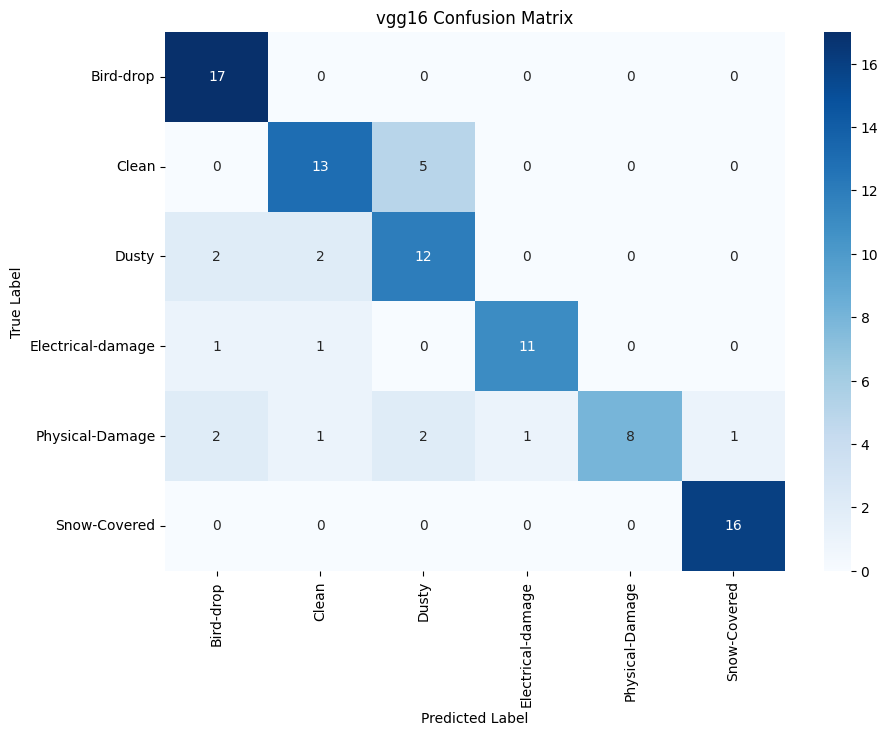

In [ ]:
# Plot a confusion matrix to see the predictions for each class

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("vgg16 Confusion Matrix")
plt.show()


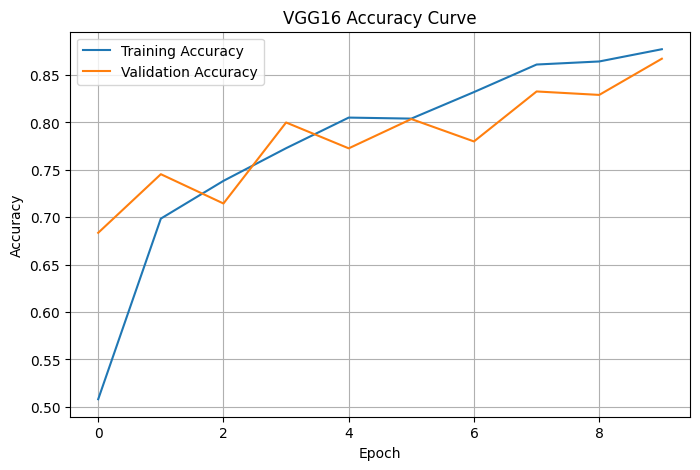

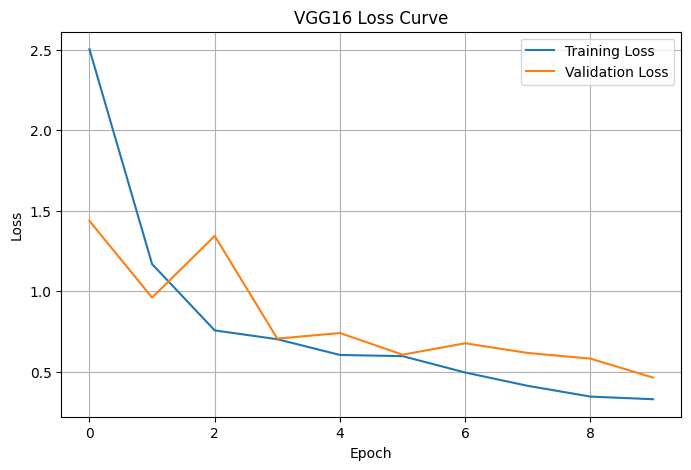

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
